# 272. Swiss-Prot feature placement by every tool, on every report-half feature

[Notebook 244](https://github.com/seanome/2024-kmerseek-analysis/blob/olgabot/244-all-case-figures/notebooks/244_hero_example_candidates.ipynb)
picked 183 cases where kmerseek places a short human Swiss-Prot feature on its counterpart in
another species and the structure tools do not. Its "Open Questions" board then asked six
questions of those 183 and could answer none of them: every question is about how the
tools behave in general, and the 183 were picked where kmerseek wins. Here each question is
asked of every report-half feature, in each of the nine species. The 183 are marked as one
group inside each answer.

**Data.** midi-plus run (998 human queries against nine QfO target proteomes; on the laptop
at `~/data/qfo-pfam-region-midi-plus`), the run notebooks 220-244 read. Truth: the human
Swiss-Prot features that notebook 231 reads (`truth_swissprot/human_swissprot_truth.parquet`).
Every tool's best call on each feature in each species comes from the landing tables
written on Sherlock by `scripts/reduce_swissprot_instance_landing.py` (the pipeline's own
region loading and label transfer). No search was run for this notebook. Question 6 also
reads `tables/272_landing_target_ranks.csv`, written on Sherlock by
`scripts/rank_272_landing_targets.py` from the run's region tables.

**Query: human. Targets: arabidopsis, chicken, ciona, E. coli, fly, mouse, worm, yeast,
zebrafish.** Only report-half query proteins are used: notebook 244 chose each feature
type's kmerseek setting on the other half (`tables/244_chosen_arm_by_type.csv`). SITE is
left out: its chosen setting placed 0 of 216 choose-half features.

**Tools.** kmerseek with the setting chosen for the feature's type (alphabet and k named in
every figure), phmmer, MMseqs2, MMseqs2 iterative, Foldseek, ProstT5, Reseek, and the
Kyte-Doolittle scan (window 19, mean hydropathy above 1.6; it reads the human sequence only,
so it gives the same call in every species).

**Definitions.**

- *Pair*: one human feature and one target species.
- *Call*: a tool's best region on the human protein that carries the feature's type (the
  type comes from a Swiss-Prot feature the region covers on the target protein) and
  overlaps the feature.
- *IoU*: overlap between the call and the feature divided by their union, computed here with
  one rule for every tool from 1-based inclusive coordinates; 0 when there is no call.
- *Lands* (kmerseek): at least 80% of the call is inside the feature and the call covers at
  least 30% of the feature.
- *Spills*: the call overlaps the feature and runs past at least one of its ends.

**Decision rules, written before running.**

1. A feature type counts as one kmerseek places tighter than the aligners if, on the pairs
   where any of the eight tools makes a call, kmerseek's IoU beats the best aligner's on at
   least half of them.
2. "Structure tools overshoot short features" holds in general if the median Foldseek and
   ProstT5 call that spills is at least twice the feature's length on all pairs, not only on
   the 183 (where it was 7.35 and 7.86 times).
3. The H/P string predicts a tight kmerseek call if, within each feature type with at least
   30 landing calls, mean IoU rises from runs under 10 to runs of 20 or more.
4. kmerseek finds features no aligner finds if, on at least 10% of pairs, kmerseek makes a
   call and none of the six aligners does.
5. kmerseek is not the tool for placing a feature type if another tool's IoU beats
   kmerseek's by more than 0.1 on more than half of the pairs where any tool calls.
6. A reader of kmerseek's ranked hit list would find a landing call if its target protein
   is in the top 10 of the run's ranking for at least half of the landing calls.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import hero_example_utils as he
import mhc_region_utils as mu

plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight", "font.size": 9.5})
pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(200)

FIG = Path("../figures")
TAB = Path("../tables")
KEY = ["accession", "pfam_id", "domain_start", "domain_end"]
ON = KEY + ["species"]
#: Colours shared with notebook 244's board: one per tool group.
KM_C, SEQ_C, STR_C, KD_C = "#d4520f", "#2a64b0", "#0e8a7d", "#7d8088"
SEQ_T, STR_T = he.ALIGNER_LABELS[:3], he.ALIGNER_LABELS[3:]
TOOL_C = {
    "kmerseek": KM_C,
    **{t: SEQ_C for t in SEQ_T},
    **{t: STR_C for t in STR_T},
    "Kyte-Doolittle scan": KD_C,
}
#: Gap in IoU that counts as one tool beating another (the board's Question 5 used 0.1).
IOU_GAP = 0.1

CHOSEN = pl.read_csv(TAB / "244_chosen_arm_by_type.csv").filter(
    pl.col("pfam_id") != "SITE"
)
SETTING = {
    r["pfam_id"]: f"{r['alphabet']} k{r['k']}" for r in CHOSEN.iter_rows(named=True)
}
KM_TOOLS = "kmerseek, one setting per feature type: " + "; ".join(
    f"{t} {s}" for t, s in SETTING.items()
)

L = he.load_landing()
P = he.report_pairs(L, he.load_instances(), CHOSEN)
cases = (
    pl.read_csv(TAB / "244_hero_candidates.csv", infer_schema_length=None)
    .with_row_index("case_id")
    .select(
        pl.col("case_id").cast(pl.Int64),
        pl.col("query").alias("accession"),
        pl.col("feature_type").alias("pfam_id"),
        pl.col("feature_start").alias("domain_start"),
        pl.col("feature_end").alias("domain_end"),
        "species",
    )
)
P = P.join(cases, on=ON, how="left").with_columns(
    in_183=pl.col("case_id").is_not_null()
)
P = P.with_columns(
    any_call=pl.any_horizontal([pl.col(f"{t}|iou") > 0 for t in he.TOOLS_272]),
    best_aligner_iou=pl.max_horizontal([pl.col(f"{t}|iou") for t in he.ALIGNER_LABELS]),
    best_other_iou=pl.max_horizontal([pl.col(f"{t}|iou") for t in he.TOOLS_272[1:]]),
)
assert P.filter("in_183").height == cases.height, P.filter("in_183").height

summary = (
    P.group_by("species")
    .agg(
        pairs=pl.len(),
        some_tool_calls=pl.col("any_call").sum(),
        kmerseek_lands=pl.col("km_landed").sum(),
        any_call_of_the_type_from_any_run_setting=pl.col("reachable").sum(),
        in_183=pl.col("in_183").sum(),
    )
    .sort("species")
)
print(
    f"report-half features: {P.select(KEY).n_unique()} on {P['accession'].n_unique()} human proteins, "
    f"{P['pfam_id'].n_unique()} feature types; pairs (feature x species): {P.height}"
)
print(summary)

report-half features: 3110 on 491 human proteins, 10 feature types; pairs (feature x species): 27990
shape: (9, 6)
┌─────────────┬───────┬─────────────────┬────────────────┬─────────────────────────────────┬────────┐
│ species     ┆ pairs ┆ some_tool_calls ┆ kmerseek_lands ┆ any_call_of_the_type_from_any_… ┆ in_183 │
│ ---         ┆ ---   ┆ ---             ┆ ---            ┆ ---                             ┆ ---    │
│ str         ┆ u32   ┆ u32             ┆ u32            ┆ u32                             ┆ u32    │
╞═════════════╪═══════╪═════════════════╪════════════════╪═════════════════════════════════╪════════╡
│ arabidopsis ┆ 3110  ┆ 3108            ┆ 1408           ┆ 3110                            ┆ 12     │
│ chicken     ┆ 3110  ┆ 3090            ┆ 864            ┆ 3106                            ┆ 17     │
│ ciona       ┆ 3110  ┆ 2632            ┆ 12             ┆ 2618                            ┆ 0      │
│ ecoli       ┆ 3110  ┆ 3001            ┆ 837            ┆ 3043      

## The pairs

Each bar is one species. The full bar is every report-half feature; the darker parts are
the pairs where at least one of the eight tools makes a call, and where kmerseek's call
lands. *A call of the type from any run setting* counts a pair when any of the run's 407
kmerseek settings or six aligners has a call of the feature's type on it; it was meant to
separate "nothing to find in this species" from "missed", and the table shows it cannot.

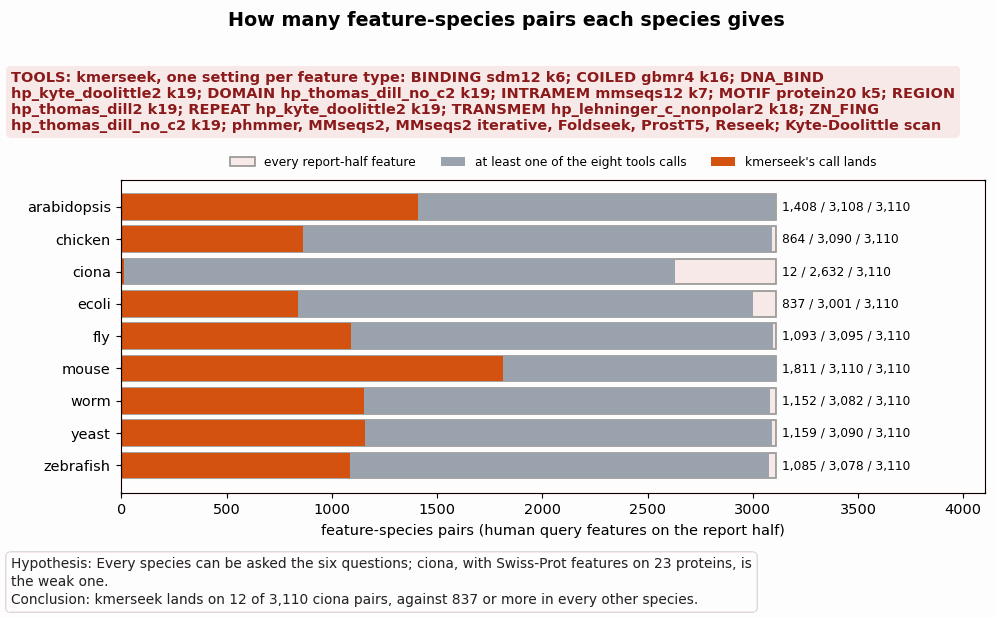

In [2]:
fig, ax = plt.subplots(figsize=(9, 3.8))
sp = summary["species"].to_list()
y = np.arange(len(sp))
ax.barh(
    y,
    summary["pairs"],
    color="#e8e7e2",
    edgecolor="#8d8c86",
    label="every report-half feature",
)
ax.barh(
    y,
    summary["some_tool_calls"],
    color="#9aa3ad",
    label="at least one of the eight tools calls",
)
ax.barh(y, summary["kmerseek_lands"], color=KM_C, label="kmerseek's call lands")
for yy, r in zip(y, summary.iter_rows(named=True)):
    ax.text(
        r["pairs"] + 30,
        yy,
        f"{r['kmerseek_lands']:,} / {r['some_tool_calls']:,} / {r['pairs']:,}",
        va="center",
        fontsize=8,
    )
ax.set_yticks(y, sp)
ax.invert_yaxis()
ax.set_xlim(0, summary["pairs"].max() * 1.32)
ax.set_xlabel("feature-species pairs (human query features on the report half)")
ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False, fontsize=8
)
ciona = summary.filter(pl.col("species") == "ciona").row(0, named=True)
mu.finish_figure(
    fig,
    FIG / "272_swissprot_pairs_per_species.png",
    tools=KM_TOOLS
    + "; phmmer, MMseqs2, MMseqs2 iterative, Foldseek, ProstT5, Reseek; Kyte-Doolittle scan",
    hypothesis="Every species can be asked the six questions; ciona, with Swiss-Prot features on 23 proteins, is the weak one.",
    conclusion=f"kmerseek lands on {ciona['kmerseek_lands']} of {ciona['pairs']:,} ciona pairs, against {summary.filter(pl.col('species') != 'ciona')['kmerseek_lands'].min():,} or more in every other species.",
    title="How many feature-species pairs each species gives",
)

## Question 1. Which feature types does kmerseek place tighter than every aligner?

Over the pairs where any of the eight tools makes a call, kmerseek's IoU against the best of
the six aligners' IoU on the same pair (a miss is IoU 0). Decision rule 1: kmerseek tighter
on at least half.

shape: (10, 9)
┌──────────┬──────┬──────────────────┬─────────────────┬───────┬─────────────────────────┬──────────┬──────────────────────────────┬───────────────┐
│ pfam_id  ┆ n    ┆ kmerseek_tighter ┆ aligner_tighter ┆ tie   ┆ kmerseek_tighter_in_183 ┆ n_in_183 ┆ setting                      ┆ passes_rule_1 │
│ ---      ┆ ---  ┆ ---              ┆ ---             ┆ ---   ┆ ---                     ┆ ---      ┆ ---                          ┆ ---           │
│ str      ┆ u32  ┆ f64              ┆ f64             ┆ f64   ┆ f64                     ┆ u32      ┆ str                          ┆ bool          │
╞══════════╪══════╪══════════════════╪═════════════════╪═══════╪═════════════════════════╪══════════╪══════════════════════════════╪═══════════════╡
│ TRANSMEM ┆ 4885 ┆ 0.716            ┆ 0.271           ┆ 0.013 ┆ 1.0                     ┆ 11       ┆ hp_lehninger_c_nonpolar2 k18 ┆ true          │
│ REPEAT   ┆ 2065 ┆ 0.366            ┆ 0.633           ┆ 0.0   ┆ 0.652                   ┆ 

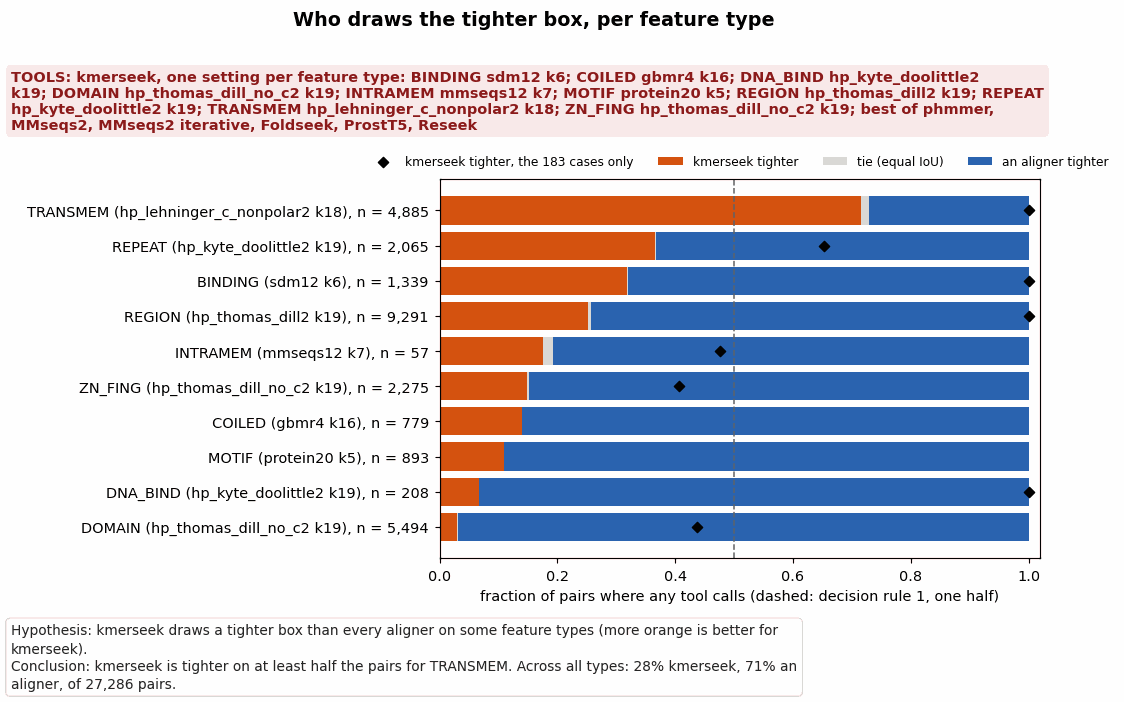

In [3]:
q1 = P.filter("any_call").with_columns(
    who=pl.when(pl.col("kmerseek|iou") > pl.col("best_aligner_iou"))
    .then(pl.lit("kmerseek tighter"))
    .when(pl.col("kmerseek|iou") < pl.col("best_aligner_iou"))
    .then(pl.lit("an aligner tighter"))
    .otherwise(pl.lit("tie"))
)
Q1 = (
    q1.group_by("pfam_id")
    .agg(
        n=pl.len(),
        kmerseek_tighter=(pl.col("who") == "kmerseek tighter").mean(),
        aligner_tighter=(pl.col("who") == "an aligner tighter").mean(),
        tie=(pl.col("who") == "tie").mean(),
        kmerseek_tighter_in_183=pl.col("who")
        .filter(pl.col("in_183"))
        .eq("kmerseek tighter")
        .mean(),
        n_in_183=pl.col("in_183").sum(),
    )
    .with_columns(
        setting=pl.col("pfam_id").replace_strict(SETTING),
        passes_rule_1=pl.col("kmerseek_tighter") >= 0.5,
    )
    .sort("kmerseek_tighter", descending=True)
)
print(Q1.with_columns(pl.col(pl.Float64).round(3)))
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ty = Q1["pfam_id"].to_list()
y = np.arange(len(ty))
left = np.zeros(len(ty))
for col, lab, c in [
    ("kmerseek_tighter", "kmerseek tighter", KM_C),
    ("tie", "tie (equal IoU)", "#d9d3c4"),
    ("aligner_tighter", "an aligner tighter", SEQ_C),
]:
    v = Q1[col].to_numpy()
    ax.barh(y, v, left=left, color=c, label=lab)
    left += v
ax.scatter(
    Q1["kmerseek_tighter_in_183"],
    y,
    marker="D",
    color="black",
    s=22,
    zorder=3,
    label="kmerseek tighter, the 183 cases only",
)
ax.axvline(0.5, color="#5d636b", ls="--", lw=1)
ax.set_yticks(y, [f"{t} ({SETTING[t]}), n = {n:,}" for t, n in zip(ty, Q1["n"])])
ax.invert_yaxis()
ax.set_xlim(0, 1.02)
ax.set_xlabel(
    "fraction of pairs where any tool calls (dashed: decision rule 1, one half)"
)
ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=4, frameon=False, fontsize=8
)
win = Q1.filter("passes_rule_1")["pfam_id"].to_list()
mu.finish_figure(
    fig,
    FIG / "272_swissprot_q1_kmerseek_vs_best_aligner_by_type.png",
    tools=KM_TOOLS
    + "; best of phmmer, MMseqs2, MMseqs2 iterative, Foldseek, ProstT5, Reseek",
    hypothesis="kmerseek draws a tighter box than every aligner on some feature types (more orange is better for kmerseek).",
    conclusion=(
        f"kmerseek is tighter on at least half the pairs for {', '.join(win)}."
        if win
        else "kmerseek is tighter on half the pairs for no feature type."
    )
    + f" Across all types: {q1['who'].eq('kmerseek tighter').mean():.0%} kmerseek, {q1['who'].eq('an aligner tighter').mean():.0%} an aligner, of {q1.height:,} pairs.",
    title="Who draws the tighter box, per feature type",
)

## Question 2. When Foldseek and ProstT5 spill, how far past the feature do they go?

Every call that overlaps a feature and runs past one of its ends, as call length divided by
feature length. The 183 cases are shown next to all pairs. Decision rule 2: median at least
2 for Foldseek and ProstT5 on all pairs.

shape: (8, 5)
┌─────────────────────┬────────────┬──────────────┬─────────────────────┬──────────┐
│ tool                ┆ n_spilling ┆ median_ratio ┆ median_ratio_in_183 ┆ n_in_183 │
│ ---                 ┆ ---        ┆ ---          ┆ ---                 ┆ ---      │
│ str                 ┆ u32        ┆ f64          ┆ f64                 ┆ u32      │
╞═════════════════════╪════════════╪══════════════╪═════════════════════╪══════════╡
│ kmerseek            ┆ 9049       ┆ 1.05         ┆ 1.08                ┆ 105      │
│ phmmer              ┆ 10630      ┆ 3.22         ┆ 2.36                ┆ 169      │
│ MMseqs2             ┆ 10615      ┆ 5.29         ┆ 3.21                ┆ 176      │
│ MMseqs2 iterative   ┆ 9914       ┆ 4.49         ┆ 2.91                ┆ 165      │
│ Foldseek            ┆ 21115      ┆ 5.43         ┆ 7.35                ┆ 179      │
│ ProstT5             ┆ 22394      ┆ 5.58         ┆ 7.86                ┆ 182      │
│ Reseek              ┆ 23027      ┆ 2.38         ┆

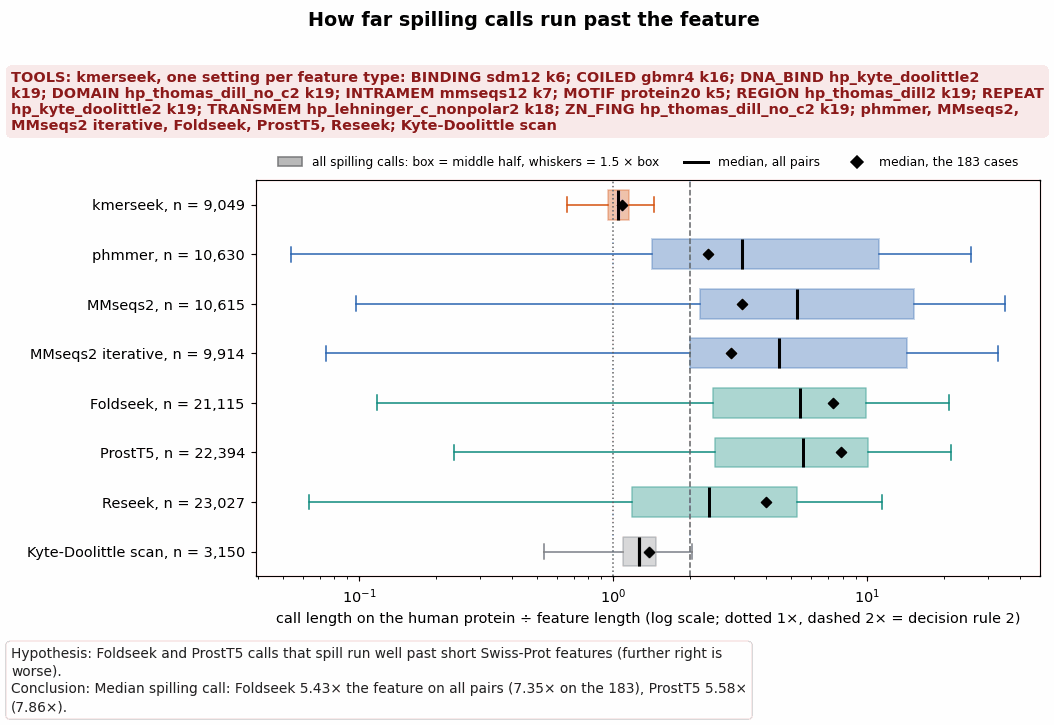

In [4]:
rows = []
for t in he.TOOLS_272:
    s = (
        P.filter(pl.col(f"{t}|iou") > 0)
        .filter(
            (pl.col(f"{t}|qstart") < pl.col("domain_start"))
            | (pl.col(f"{t}|qend") > pl.col("domain_end"))
        )
        .with_columns(
            ratio=(pl.col(f"{t}|qend") - pl.col(f"{t}|qstart") + 1)
            / pl.col("feature_length")
        )
    )
    rows.append(s.select(pl.lit(t).alias("tool"), "ratio", "in_183", "pfam_id"))
SP = pl.concat(rows)
Q2 = SP.group_by("tool", maintain_order=True).agg(
    n_spilling=pl.len(),
    median_ratio=pl.col("ratio").median(),
    median_ratio_in_183=pl.col("ratio").filter(pl.col("in_183")).median(),
    n_in_183=pl.col("in_183").sum(),
)
print(Q2.with_columns(pl.col(pl.Float64).round(2)))
fig, ax = plt.subplots(figsize=(9.5, 4.6))
for i, t in enumerate(he.TOOLS_272):
    v = SP.filter(pl.col("tool") == t)["ratio"].to_numpy()
    if len(v):
        ax.boxplot(
            [v],
            positions=[i],
            widths=0.6,
            vert=False,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(facecolor=TOOL_C[t], alpha=0.35, edgecolor=TOOL_C[t]),
            medianprops=dict(color="black", lw=2),
            whiskerprops=dict(color=TOOL_C[t]),
            capprops=dict(color=TOOL_C[t]),
        )
    m = Q2.filter(pl.col("tool") == t)["median_ratio_in_183"].to_list()
    if m and m[0] is not None:
        ax.scatter([m[0]], [i], marker="D", color="black", s=22, zorder=3)
ax.axvline(1, color="#5d636b", ls=":", lw=1)
ax.axvline(2, color="#5d636b", ls="--", lw=1)
ax.set_xscale("log")
ax.set_yticks(
    range(len(he.TOOLS_272)),
    [f"{t}, n = {n:,}" for t, n in zip(Q2["tool"], Q2["n_spilling"])],
)
ax.invert_yaxis()
ax.set_xlabel(
    "call length on the human protein ÷ feature length (log scale; dotted 1×, dashed 2× = decision rule 2)"
)
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

ax.legend(
    handles=[
        Patch(
            facecolor="#bbbbbb",
            edgecolor="#777777",
            label="all spilling calls: box = middle half, whiskers = 1.5 × box",
        ),
        Line2D([], [], color="black", lw=2, label="median, all pairs"),
        Line2D([], [], marker="D", ls="", color="black", label="median, the 183 cases"),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,
    frameon=False,
    fontsize=8,
)
fs, pt = (
    Q2.filter(pl.col("tool") == t).row(0, named=True) for t in ("Foldseek", "ProstT5")
)
mu.finish_figure(
    fig,
    FIG / "272_swissprot_q2_spill_length.png",
    tools=KM_TOOLS
    + "; phmmer, MMseqs2, MMseqs2 iterative, Foldseek, ProstT5, Reseek; Kyte-Doolittle scan",
    hypothesis="Foldseek and ProstT5 calls that spill run well past short Swiss-Prot features (further right is worse).",
    conclusion=f"Median spilling call: Foldseek {fs['median_ratio']:.2f}× the feature on all pairs ({fs['median_ratio_in_183']:.2f}× on the 183), ProstT5 {pt['median_ratio']:.2f}× ({pt['median_ratio_in_183']:.2f}×).",
    title="How far spilling calls run past the feature",
)

## Question 3. Does the H/P string alone predict a tight kmerseek box?

For every kmerseek call that lands: write the human and target residues of the call in the
two-letter hp_thomas_dill2 alphabet (H = ACFILMVWY, the rest P) and take the longest
unbroken stretch where both are in the same class. Decision rule 3: within each feature type
with at least 30 landing calls, mean IoU rises from runs under 10 to runs of 20 or more.
Two things limit the reading. The run cannot be longer than the call, so a longer run also
means a longer call (the table gives the mean call length per group). And for REGION, whose
setting is hp_thomas_dill2 itself, every landing call is one unbroken run end to end; DOMAIN
and ZN_FING use hp_thomas_dill_no_c2, which differs only in where C goes.

shape: (24, 5)
┌──────────┬────────────┬──────┬──────────┬──────────────┐
│ pfam_id  ┆ run_bin    ┆ n    ┆ mean_iou ┆ mean_call_aa │
│ ---      ┆ ---        ┆ ---  ┆ ---      ┆ ---          │
│ str      ┆ str        ┆ u32  ┆ f64      ┆ f64          │
╞══════════╪════════════╪══════╪══════════╪══════════════╡
│ BINDING  ┆ 10 to 19   ┆ 14   ┆ 0.9      ┆ 10.0         │
│ BINDING  ┆ under 10   ┆ 41   ┆ 0.995    ┆ 8.780488     │
│ COILED   ┆ 10 to 19   ┆ 84   ┆ 0.582    ┆ 22.75        │
│ COILED   ┆ 20 or more ┆ 22   ┆ 0.635    ┆ 35.409091    │
│ COILED   ┆ under 10   ┆ 81   ┆ 0.584    ┆ 22.061728    │
│ DNA_BIND ┆ 10 to 19   ┆ 5    ┆ 0.542    ┆ 23.6         │
│ DNA_BIND ┆ 20 or more ┆ 18   ┆ 0.653    ┆ 50.055556    │
│ DOMAIN   ┆ 10 to 19   ┆ 194  ┆ 0.474    ┆ 26.28866     │
│ DOMAIN   ┆ 20 or more ┆ 307  ┆ 0.616    ┆ 56.618893    │
│ DOMAIN   ┆ under 10   ┆ 234  ┆ 0.465    ┆ 25.910256    │
│ INTRAMEM ┆ 10 to 19   ┆ 17   ┆ 0.543    ┆ 11.176471    │
│ INTRAMEM ┆ under 10   ┆ 6    ┆ 0.424   

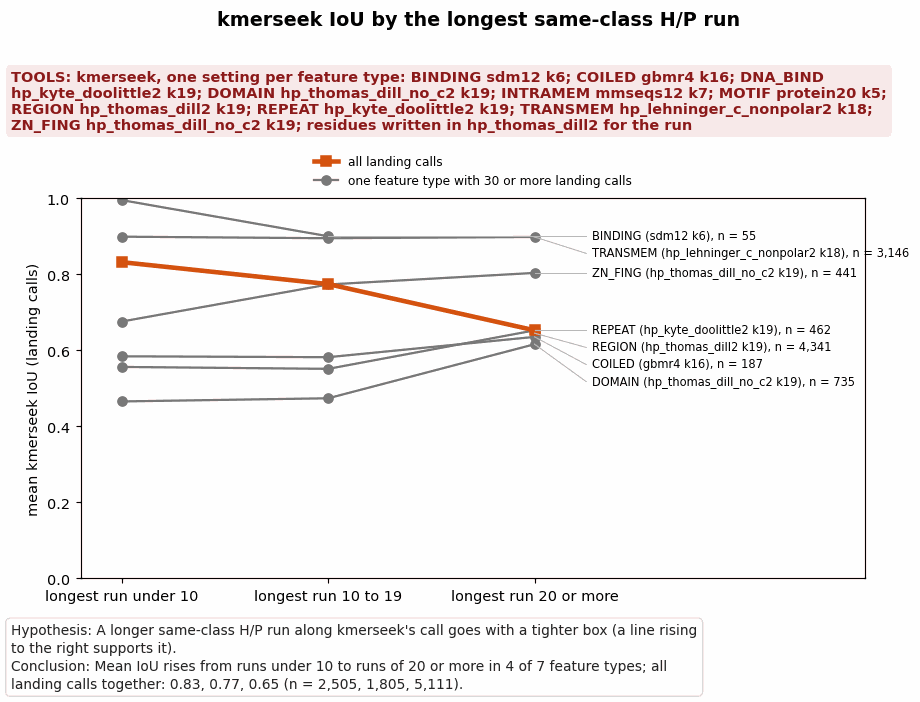

In [5]:
HP_ALPHA = "hp_thomas_dill2"
MIN_CALLS = 30
land = P.filter("km_landed")
hseq = he.sequences("human", set(land["accession"]))
tres = {}
for sp in he.SPECIES:
    sub = land.filter(pl.col("species") == sp)
    tres[sp] = he.sequences(sp, set(sub["km_land_target"]))
runs = []
for r in land.iter_rows(named=True):
    h = hseq[r["accession"]][r["km_land_qstart"] - 1 : r["km_land_qend"]]
    t = tres[r["species"]][r["km_land_target"]][
        r["km_land_tstart"] - 1 : r["km_land_tend"]
    ]
    runs.append(
        {
            **{k: r[k] for k in ON},
            "km_hres": h,
            "km_tres": t,
            "hp_run": he.longest_same_class_run(h, t, HP_ALPHA),
        }
    )
RUNS = pl.DataFrame(runs)
P = P.join(RUNS, on=ON, how="left")
land = P.filter("km_landed").with_columns(
    run_bin=pl.when(pl.col("hp_run") < 10)
    .then(pl.lit("under 10"))
    .when(pl.col("hp_run") < 20)
    .then(pl.lit("10 to 19"))
    .otherwise(pl.lit("20 or more"))
)
BINS = ["under 10", "10 to 19", "20 or more"]
Q3 = land.group_by("pfam_id", "run_bin").agg(
    n=pl.len(),
    mean_iou=pl.col("km_land_iou").mean(),
    mean_call_aa=(pl.col("km_land_qend") - pl.col("km_land_qstart") + 1).mean(),
)
big = (
    land.group_by("pfam_id")
    .len()
    .filter(pl.col("len") >= MIN_CALLS)["pfam_id"]
    .to_list()
)
Q3w = (
    Q3.filter(pl.col("pfam_id").is_in(big))
    .pivot(on="run_bin", index="pfam_id", values="mean_iou")
    .select("pfam_id", *[b for b in BINS if b in Q3["run_bin"].unique()])
)
Q3w = Q3w.with_columns(
    rises=(
        pl.col("20 or more") > pl.col("under 10")
        if "under 10" in Q3w.columns
        else pl.lit(None)
    )
)
print(Q3.sort("pfam_id", "run_bin").with_columns(pl.col("mean_iou").round(3)))
print(Q3w.with_columns(pl.col(pl.Float64).round(3)))
fig, ax = plt.subplots(figsize=(8.5, 4.4))
types = sorted(big)
ends = []
for i, t in enumerate(types):
    d = Q3.filter(pl.col("pfam_id") == t)
    xs = [BINS.index(b) for b in d["run_bin"]]
    order = np.argsort(xs)
    xs = np.array(xs)[order]
    ys = d["mean_iou"].to_numpy()[order]
    ns = d["n"].to_numpy()[order]
    ax.plot(xs, ys, marker="o", color="#777777", lw=1.5)
    ends.append((ys[-1], xs[-1], f"{t} ({SETTING[t]}), n = {ns.sum():,}"))
allm = land.group_by("run_bin").agg(pl.col("km_land_iou").mean(), pl.len())
allm = allm.sort(pl.col("run_bin").replace_strict({b: i for i, b in enumerate(BINS)}))
ax.plot(
    range(len(allm)),
    allm["km_land_iou"],
    color=KM_C,
    lw=3,
    marker="s",
    label="all landing calls",
)
# Labels at the right edge, spread so no two overlap, each joined to its line's last point.
ends.sort(reverse=True)
ylab = []
for y0, _, _ in ends:
    y1 = min(y0, ylab[-1] - 0.045) if ylab else y0
    ylab.append(y1)
for (y0, x0, lab), y1 in zip(ends, ylab):
    ax.plot([x0, 2.25], [y0, y1], color="#bbbbbb", lw=0.8)
    ax.text(2.28, y1, lab, va="center", fontsize=7.5)
ax.set_xticks(range(3), [f"longest run {b}" for b in BINS])
ax.set_xlim(-0.2, 3.6)
ax.set_ylim(0, 1)
ax.set_ylabel("mean kmerseek IoU (landing calls)")
from matplotlib.lines import Line2D

ax.legend(
    handles=[
        Line2D([], [], color=KM_C, lw=3, marker="s", label="all landing calls"),
        Line2D(
            [],
            [],
            color="#777777",
            lw=1.5,
            marker="o",
            label=f"one feature type with {MIN_CALLS} or more landing calls",
        ),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=1,
    frameon=False,
    fontsize=8,
)
nrise = int(Q3w["rises"].sum()) if "rises" in Q3w.columns else 0
mu.finish_figure(
    fig,
    FIG / "272_swissprot_q3_hp_run_vs_iou.png",
    tools=KM_TOOLS + "; residues written in hp_thomas_dill2 for the run",
    hypothesis="A longer same-class H/P run along kmerseek's call goes with a tighter box (a line rising to the right supports it).",
    conclusion=f"Mean IoU rises from runs under 10 to runs of 20 or more in {nrise} of {Q3w.height} feature types; all landing calls together: {', '.join(f'{v:.2f}' for v in allm['km_land_iou'])} (n = {', '.join(f'{n:,}' for n in allm['len'])}).",
    title="kmerseek IoU by the longest same-class H/P run",
)

## Question 4. Which pairs does every tool miss, and which does only kmerseek find?

Per species, over all pairs: no tool calls; only kmerseek calls; kmerseek and an aligner
both call; only aligners (or the scan) call. Decision rule 4: kmerseek alone calls on at
least 10% of pairs. A pair where no tool calls may have nothing to find; the first table
showed that "a call of the type from any setting" cannot tell those apart, so the counts are
per species, with ciona (Swiss-Prot features on 23 proteins) shown on its own row.

shape: (9, 6)
┌─────────────┬─────────────────────────────────┬─────────────────────────┬─────────────────────────────────┬───────────────┬───────┐
│ species     ┆ only kmerseek (and perhaps the… ┆ kmerseek and an aligner ┆ aligners or the scan, not kmer… ┆ no tool calls ┆ pairs │
│ ---         ┆ ---                             ┆ ---                     ┆ ---                             ┆ ---           ┆ ---   │
│ str         ┆ u32                             ┆ u32                     ┆ u32                             ┆ u32           ┆ u32   │
╞═════════════╪═════════════════════════════════╪═════════════════════════╪═════════════════════════════════╪═══════════════╪═══════╡
│ arabidopsis ┆ 73                              ┆ 2337                    ┆ 698                             ┆ 2             ┆ 3110  │
│ chicken     ┆ 20                              ┆ 1930                    ┆ 1140                            ┆ 20            ┆ 3110  │
│ ciona       ┆ 7                               

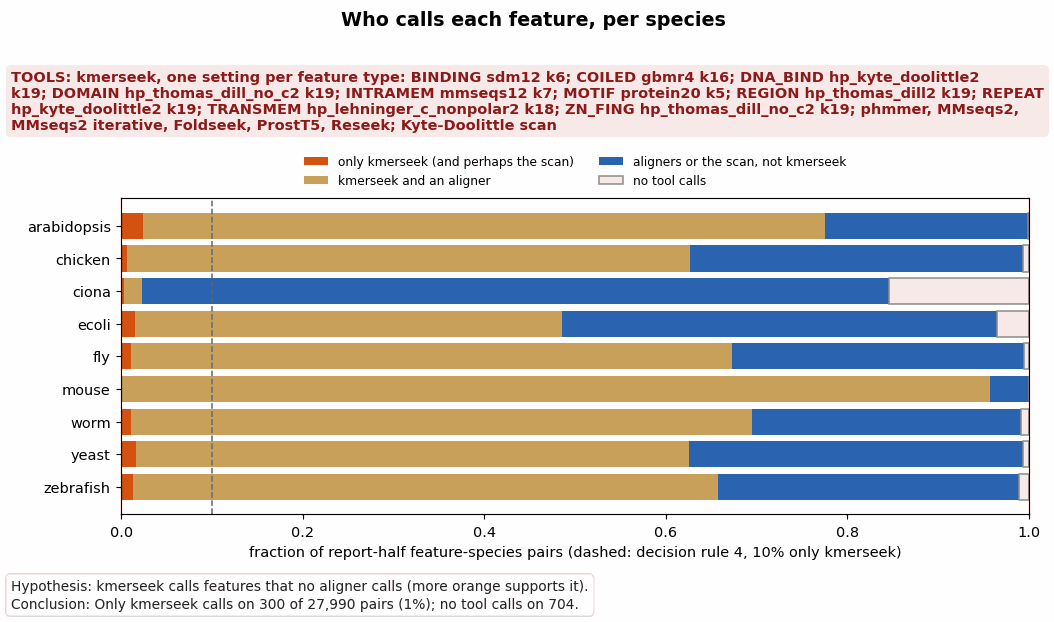

In [6]:
q4 = P.with_columns(
    aligner_calls=pl.any_horizontal(
        [pl.col(f"{t}|iou") > 0 for t in he.ALIGNER_LABELS]
    ),
    other_calls=pl.any_horizontal([pl.col(f"{t}|iou") > 0 for t in he.TOOLS_272[1:]]),
    km_calls=pl.col("kmerseek|iou") > 0,
).with_columns(
    group=pl.when(~pl.col("km_calls") & ~pl.col("other_calls"))
    .then(pl.lit("no tool calls"))
    .when(pl.col("km_calls") & ~pl.col("aligner_calls"))
    .then(pl.lit("only kmerseek (and perhaps the scan)"))
    .when(pl.col("km_calls"))
    .then(pl.lit("kmerseek and an aligner"))
    .otherwise(pl.lit("aligners or the scan, not kmerseek"))
)
GROUPS = [
    "only kmerseek (and perhaps the scan)",
    "kmerseek and an aligner",
    "aligners or the scan, not kmerseek",
    "no tool calls",
]
GC = {GROUPS[0]: KM_C, GROUPS[1]: "#c9a15a", GROUPS[2]: SEQ_C, GROUPS[3]: "#e8e7e2"}
Q4 = (
    q4.group_by("species", "group")
    .len()
    .pivot(on="group", index="species", values="len")
    .fill_null(0)
    .sort("species")
)
Q4 = Q4.select("species", *GROUPS).with_columns(pairs=pl.sum_horizontal(GROUPS))
print(Q4)
tot = q4["group"].value_counts().sort("count", descending=True)
print(tot)
print("only kmerseek, by feature type:")
print(
    q4.group_by("pfam_id")
    .agg(pairs=pl.len(), only_kmerseek=(pl.col("group") == GROUPS[0]).sum())
    .sort("only_kmerseek", descending=True)
)
fig, ax = plt.subplots(figsize=(9.5, 4))
y = np.arange(Q4.height)
left = np.zeros(Q4.height)
for g in GROUPS:
    v = (Q4[g] / Q4["pairs"]).to_numpy()
    ax.barh(
        y,
        v,
        left=left,
        color=GC[g],
        edgecolor="#8d8c86" if g == GROUPS[3] else None,
        label=g,
    )
    left += v
ax.axvline(0.1, color="#5d636b", ls="--", lw=1)
ax.set_yticks(y, Q4["species"])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel(
    "fraction of report-half feature-species pairs (dashed: decision rule 4, 10% only kmerseek)"
)
ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False, fontsize=8
)
n_only = int((q4["group"] == GROUPS[0]).sum())
mu.finish_figure(
    fig,
    FIG / "272_swissprot_q4_who_calls_per_species.png",
    tools=KM_TOOLS
    + "; phmmer, MMseqs2, MMseqs2 iterative, Foldseek, ProstT5, Reseek; Kyte-Doolittle scan",
    hypothesis="kmerseek calls features that no aligner calls (more orange supports it).",
    conclusion=f"Only kmerseek calls on {n_only:,} of {q4.height:,} pairs ({n_only / q4.height:.0%}); no tool calls on {int((q4['group'] == GROUPS[3]).sum()):,}.",
    title="Who calls each feature, per species",
)

## Question 5. Where does kmerseek lose?

Over the pairs where any tool calls: the best other tool (six aligners and the scan) beats
kmerseek's IoU by more than 0.1, or kmerseek beats the best other tool by more than 0.1.
Decision rule 5: another tool wins on more than half of a type's pairs.

shape: (10, 7)
┌──────────┬──────┬───────────────────┬───────────────┬─────────────────────┬──────────────────────────────┬───────────────┐
│ pfam_id  ┆ n    ┆ another_tool_wins ┆ kmerseek_wins ┆ another_wins_in_183 ┆ setting                      ┆ passes_rule_5 │
│ ---      ┆ ---  ┆ ---               ┆ ---           ┆ ---                 ┆ ---                          ┆ ---           │
│ str      ┆ u32  ┆ f64               ┆ f64           ┆ f64                 ┆ str                          ┆ bool          │
╞══════════╪══════╪═══════════════════╪═══════════════╪═════════════════════╪══════════════════════════════╪═══════════════╡
│ DOMAIN   ┆ 5494 ┆ 0.936             ┆ 0.018         ┆ 0.25                ┆ hp_thomas_dill_no_c2 k19     ┆ true          │
│ DNA_BIND ┆ 208  ┆ 0.87              ┆ 0.058         ┆ 0.0                 ┆ hp_kyte_doolittle2 k19       ┆ true          │
│ COILED   ┆ 779  ┆ 0.772             ┆ 0.117         ┆ null                ┆ gbmr4 k16                    ┆ t

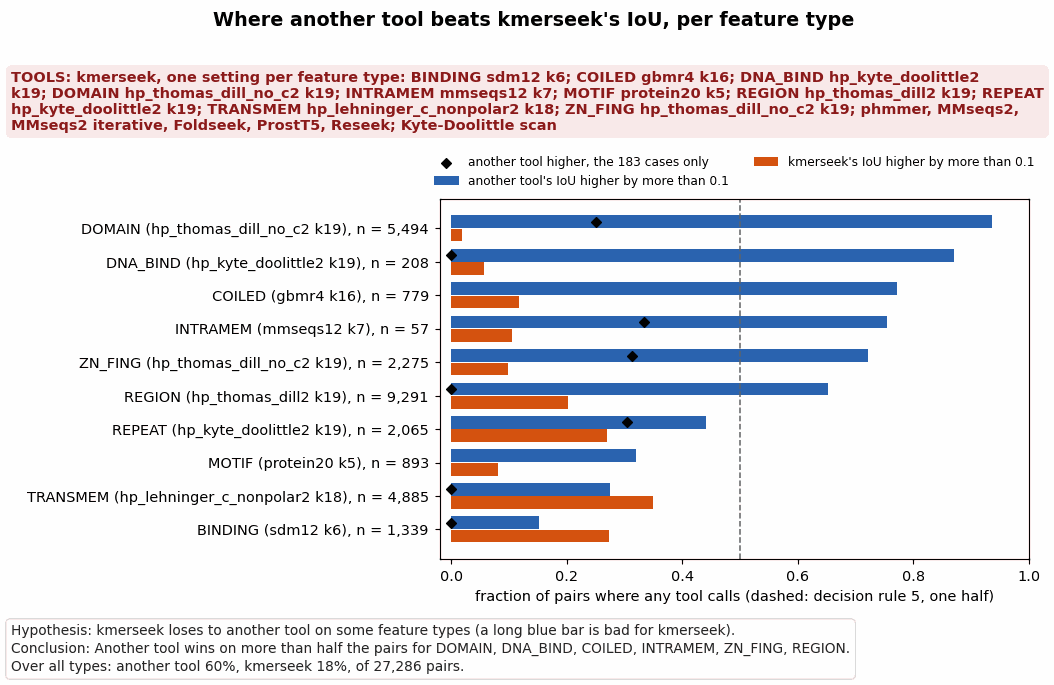

In [7]:
q5 = P.filter("any_call").with_columns(
    outcome=pl.when(pl.col("best_other_iou") - pl.col("kmerseek|iou") > IOU_GAP)
    .then(pl.lit("another tool wins"))
    .when(pl.col("kmerseek|iou") - pl.col("best_other_iou") > IOU_GAP)
    .then(pl.lit("kmerseek wins"))
    .otherwise(pl.lit("within 0.1")),
    winner=pl.concat_list(
        [pl.struct(t=pl.lit(t), v=pl.col(f"{t}|iou")) for t in he.TOOLS_272[1:]]
    )
    .list.eval(
        pl.element()
        .sort_by(pl.element().struct.field("v"), descending=True)
        .first()
        .struct.field("t")
    )
    .list.first(),
)
Q5 = (
    q5.group_by("pfam_id")
    .agg(
        n=pl.len(),
        another_tool_wins=(pl.col("outcome") == "another tool wins").mean(),
        kmerseek_wins=(pl.col("outcome") == "kmerseek wins").mean(),
        another_wins_in_183=pl.col("outcome")
        .filter(pl.col("in_183"))
        .eq("another tool wins")
        .mean(),
    )
    .with_columns(
        setting=pl.col("pfam_id").replace_strict(SETTING),
        passes_rule_5=pl.col("another_tool_wins") > 0.5,
    )
    .sort("another_tool_wins", descending=True)
)
print(Q5.with_columns(pl.col(pl.Float64).round(3)))
print("winning tool when another tool wins:")
print(
    q5.filter(pl.col("outcome") == "another tool wins")["winner"]
    .value_counts()
    .sort("count", descending=True)
)
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ty = Q5["pfam_id"].to_list()
y = np.arange(len(ty))
ax.barh(
    y - 0.2,
    Q5["another_tool_wins"],
    height=0.38,
    color=SEQ_C,
    label=f"another tool's IoU higher by more than {IOU_GAP}",
)
ax.barh(
    y + 0.2,
    Q5["kmerseek_wins"],
    height=0.38,
    color=KM_C,
    label=f"kmerseek's IoU higher by more than {IOU_GAP}",
)
ax.scatter(
    Q5["another_wins_in_183"],
    y - 0.2,
    marker="D",
    color="black",
    s=20,
    zorder=3,
    label="another tool higher, the 183 cases only",
)
ax.axvline(0.5, color="#5d636b", ls="--", lw=1)
ax.set_yticks(y, [f"{t} ({SETTING[t]}), n = {n:,}" for t, n in zip(ty, Q5["n"])])
ax.invert_yaxis()
ax.set_xlim(-0.02, 1)
ax.set_xlabel(
    "fraction of pairs where any tool calls (dashed: decision rule 5, one half)"
)
ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False, fontsize=8
)
lose = Q5.filter("passes_rule_5")["pfam_id"].to_list()
mu.finish_figure(
    fig,
    FIG / "272_swissprot_q5_where_kmerseek_loses.png",
    tools=KM_TOOLS
    + "; phmmer, MMseqs2, MMseqs2 iterative, Foldseek, ProstT5, Reseek; Kyte-Doolittle scan",
    hypothesis="kmerseek loses to another tool on some feature types (a long blue bar is bad for kmerseek).",
    conclusion=(
        f"Another tool wins on more than half the pairs for {', '.join(lose)}."
        if lose
        else "No feature type has another tool winning on more than half its pairs."
    )
    + f" Over all types: another tool {q5['outcome'].eq('another tool wins').mean():.0%}, kmerseek {q5['outcome'].eq('kmerseek wins').mean():.0%}, of {q5.height:,} pairs.",
    title="Where another tool beats kmerseek's IoU, per feature type",
)

## Question 6. Is a landing call's target near the top of kmerseek's own hit list?

For every pair where kmerseek's call lands: the rank of the target protein that call came
from, among all target proteins that kmerseek search reported for the human protein,
ranked by the run's rule (keep regions with Bonferroni-corrected tail probability under
0.05, order proteins by their best `region_enrichment`; `scripts/kmerseek_run_rank.py`).
Decision rule 6: in the top 10 for at least half of the landing calls.

In [8]:
RANK_FILE = TAB / "272_landing_target_ranks.csv"
if RANK_FILE.exists():
    import re

    ranks = pl.read_csv(RANK_FILE)

    def table_of(arm, sp):
        m = re.match(r"kmerseek\.(.+)_k(\d+)_lc(True|False)$", arm)
        return f"human_vs_{sp}.{m[1]}.k{m[2]}.lc{m[3].lower()}.regions.parquet"

    tbl = CHOSEN.select("pfam_id", "arm")
    P = (
        P.join(tbl, on="pfam_id", how="left")
        .with_columns(
            table=pl.struct("arm", "species").map_elements(
                lambda r: table_of(r["arm"], r["species"]), return_dtype=pl.String
            )
        )
        .join(
            ranks.rename({"target": "km_land_target"}),
            on=["table", "accession", "km_land_target"],
            how="left",
        )
        .drop("arm")
    )
    lr = P.filter("km_landed")
    Q6 = (
        lr.group_by("pfam_id")
        .agg(
            n=pl.len(),
            median_rank=pl.col("run_rank").median(),
            top10=(pl.col("run_rank") <= 10).mean(),
            first=(pl.col("run_rank") == 1).mean(),
            unranked=pl.col("run_rank").is_null().sum(),
            median_proteins_ranked=pl.col("n_ranked").median(),
        )
        .with_columns(setting=pl.col("pfam_id").replace_strict(SETTING))
        .sort("median_rank")
    )
    print(Q6.with_columns(pl.col(pl.Float64).round(3)))
    fig, ax = plt.subplots(figsize=(9.5, 4.4))
    ty = Q6["pfam_id"].to_list()
    for i, t in enumerate(ty):
        v = lr.filter((pl.col("pfam_id") == t) & pl.col("run_rank").is_not_null())
        jit = (np.arange(v.height) * 37 % 23 - 11) / 40
        ax.scatter(v["run_rank"], i + jit, s=4, color=KM_C, alpha=0.25)
        c = v.filter("in_183")
        ax.scatter(
            c["run_rank"],
            np.full(c.height, i),
            marker="D",
            s=16,
            color="black",
            zorder=3,
        )
        ax.plot([Q6["median_rank"][i]] * 2, [i - 0.35, i + 0.35], color="black", lw=2.5)
    ax.axvline(10, color="#5d636b", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_yticks(
        range(len(ty)), [f"{t} ({SETTING[t]}), n = {n:,}" for t, n in zip(ty, Q6["n"])]
    )
    ax.invert_yaxis()
    ax.set_xlabel(
        "rank of the landing call's target among the proteins the search reported (log; dashed: rank 10)"
    )
    from matplotlib.lines import Line2D

    ax.legend(
        handles=[
            Line2D(
                [],
                [],
                marker="o",
                ls="",
                color=KM_C,
                alpha=0.5,
                label="one landing call",
            ),
            Line2D(
                [], [], marker="D", ls="", color="black", label="one of the 183 cases"
            ),
            Line2D([], [], color="black", lw=2.5, label="median"),
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=3,
        frameon=False,
        fontsize=8,
    )
    t10 = (lr["run_rank"] <= 10).mean()
    mu.finish_figure(
        fig,
        FIG / "272_swissprot_q6_landing_target_rank.png",
        tools=KM_TOOLS
        + "; ranks from the run's region tables (scripts/rank_272_landing_targets.py)",
        hypothesis="kmerseek's landing calls come from targets near the top of its own ranked hit list (further left is better).",
        conclusion=f"The landing call's target is in the top 10 for {t10:.0%} of {lr.height:,} landing calls and first for {(lr['run_rank'] == 1).mean():.0%}; median rank {lr['run_rank'].median():.0f}.",
        title="Rank of each landing call's target in kmerseek's hit list",
    )
else:
    print(
        f"{RANK_FILE} is not here yet: run scripts/rank_272_landing_targets.sbatch on Sherlock and copy its output."
    )

../tables/272_landing_target_ranks.csv is not here yet: run scripts/rank_272_landing_targets.sbatch on Sherlock and copy its output.


## Export

One row per pair, for the board: the feature, the species, each tool's call on the human
protein and its IoU, kmerseek's landing call with its residues on both proteins, the rank
of its target, and the case number when the pair is one of the 183.

In [9]:
cols = [
    "accession",
    "hgnc_symbol",
    "pfam_id",
    "domain_start",
    "domain_end",
    "species",
    "case_id",
]
for t in he.TOOLS_272:
    cols += [f"{t}|qstart", f"{t}|qend"]
cols += [
    "km_landed",
    "km_land_qstart",
    "km_land_qend",
    "km_land_target",
    "km_land_tstart",
    "km_land_tend",
    "km_hres",
    "km_tres",
    "hp_run",
]
cols += [c for c in ("run_rank", "n_ranked") if c in P.columns]
OUT = P.select(cols)
OUT.write_csv(TAB / "272_swissprot_report_half_pairs.csv")
print(
    f"wrote {TAB / '272_swissprot_report_half_pairs.csv'}: {OUT.height:,} rows, {len(cols)} columns, "
    f"{(TAB / '272_swissprot_report_half_pairs.csv').stat().st_size / 1e6:.1f} MB"
)

wrote ../tables/272_swissprot_report_half_pairs.csv: 27,990 rows, 32 columns, 3.3 MB
